# ISyE 6525 HW1 - Question 3

Goal: estimate the sample mean discharge curve with four smoothers, using the **same 5-fold split of the 200 time points** for every reported CV MSE.

Methods:

1. Cubic truncated-power spline; choose 5--30 interior knots by CV.
2. Cubic B-spline; choose 5--30 interior knots by CV.
3. Smoothing spline; choose $\lambda$ by GCV and report $\operatorname{tr}(S_\lambda)$.
4. Gaussian kernel regression; choose bandwidth by CV.


In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.interpolate import CubicSpline
from sklearn.model_selection import KFold
from patsy import build_design_matrices, dmatrix


RANDOM_STATE = 25
N_SPLITS = 5
DATA_PATH = Path('Question3.csv')



In [25]:
##### Configure logging #####
import logging
import warnings

LOG_LEVEL = logging.WARNING

logging.basicConfig(
    level=LOG_LEVEL,
    format="%(levelname)s | %(name)s | %(message)s",
    force=True,  # reconfigure logging even if Jupyter initialized it already
)

# Reduce noise from specific libraries
for logger_name in ["matplotlib", "PIL", "sklearn"]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

# Keep warnings visible by default
warnings.filterwarnings("default")

def set_log_level(level):
    logging.getLogger().setLevel(level)

set_log_level(logging.INFO)     # change to DEBUG for more detailed output

logger = logging.getLogger(__name__)


## Load the data and compute the sample mean
For each time point \(t_j\), the sample mean is computed as follows:
$$
\bar y(t_j)=\frac{1}{50}\sum_{i=1}^{50}y_i(t_j).
$$

INFO | __main__ | y_bar shape = (200,)


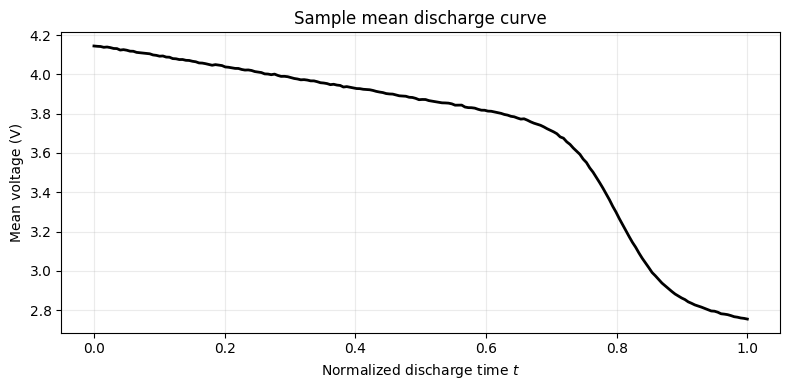

In [22]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Put {DATA_PATH.name} beside this notebook.')

profiles = pd.read_csv(DATA_PATH, header=None).to_numpy(dtype=float)
assert profiles.shape == (50, 200), f'Expected (50, 200), got {profiles.shape}'

t = np.linspace(0.0, 1.0, profiles.shape[1])
y_bar = profiles.mean(axis=0)
logger.info(f"y_bar shape = {y_bar.shape}")

plt.figure(figsize=(8, 4))
plt.plot(t, y_bar, color='black', linewidth=2)
plt.xlabel('Normalized discharge time $t$')
plt.ylabel('Mean voltage (V)')
plt.title('Sample mean discharge curve')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Common 5-fold CV setup

The split is materialized once and reused. `fit_predict` must fit only on `(t_train, y_train)` and return predictions at `t_valid`.

Keep this same `splits` object for all four methods. Do not recreate `KFold` inside a model loop.

In [23]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
splits = list(kf.split(t))

def cv_mse(fit_predict, x, y, splits, **params):
    out_of_fold = np.empty_like(y, dtype=float)
    
    logger.debug(f"x shape = {x.shape}, y shape = {y.shape}")
    logger.debug(f"Number of splits = {len(splits)}")
    for train_idx, valid_idx in splits:
        out_of_fold[valid_idx] = fit_predict(
            x[train_idx], y[train_idx], x[valid_idx], **params
        )

    return mean_squared_error(y, out_of_fold)

# Sanity check: every point should appear in exactly one validation fold.
valid_indices = np.concatenate([valid for _, valid in splits])
assert np.array_equal(np.sort(valid_indices), np.arange(len(t)))

## (a) Cubic spline with truncated-power basis

For interior knots $\xi_1,\ldots,\xi_K$, use

$$
1,t,t^2,t^3,(t-\xi_1)_+^3,\ldots,(t-\xi_K)_+^3.
$$


In [26]:
def truncated_power_design(x, knots):
    x = np.asarray(x, dtype=float)
    polynomial = np.column_stack([np.ones_like(x), x, x**2, x**3])
    logger.debug(f"Polynomial shape = {polynomial.shape}")
    logger.debug(f"x shape = {x.shape}")
    logger.debug(f"knots shape = {knots.shape}")
    truncated = np.maximum(x[:, None] - knots[None, :], 0.0) ** 3
    logger.debug(f"Truncated shape = {truncated.shape}")
    return np.column_stack([polynomial, truncated])

def truncated_power_fit_predict(x_train, y_train, x_valid, n_interior_knots):
    knots = np.linspace(0.0, 1.0, n_interior_knots + 2)[1:-1]
    model = LinearRegression(fit_intercept=False)
    basis = truncated_power_design(x_train, knots)
    logger.debug(f"Power truncated basis shape = {basis.shape}")
    model.fit(basis, y_train)
    return model.predict(truncated_power_design(x_valid, knots))

truncated_cv = {}
for K in range(5, 31):
    truncated_cv[K] = cv_mse(truncated_power_fit_predict, t, y_bar, splits, n_interior_knots=K)

best_truncated_k = min(truncated_cv, key=truncated_cv.get)
best_truncated_mse = truncated_cv[best_truncated_k]

logger.info(f"Best truncated power spline: K = {best_truncated_k}, CV MSE = {best_truncated_mse}")

INFO | __main__ | Best truncated power spline: K = 21, CV MSE = 3.2625949510904368e-06


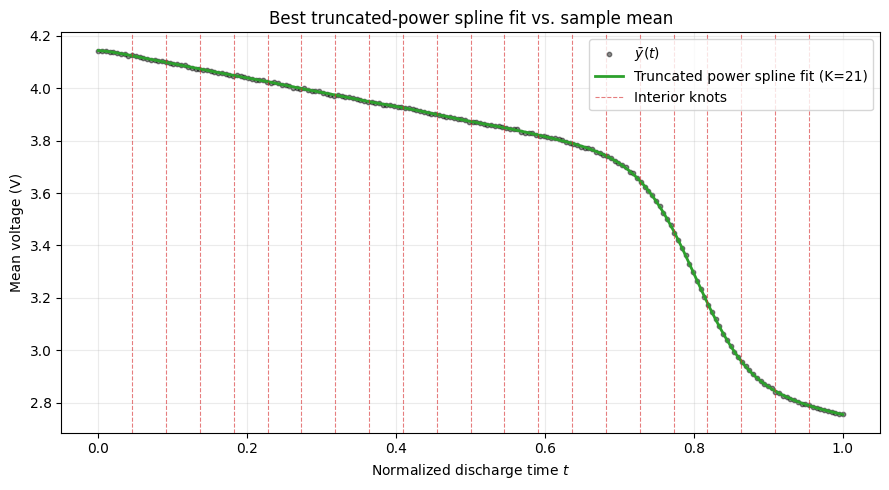

In [30]:
t_dense = np.linspace(0.0, 1.0, 1000)
y_truncated_dense = truncated_power_fit_predict(t, y_bar, t_dense, n_interior_knots=best_truncated_k)
best_truncated_knots = np.linspace(0.0, 1.0, best_truncated_k + 2)[1:-1]

plt.figure(figsize=(9, 5))
plt.scatter(t, y_bar, s=10, color='black', alpha=0.45, label=r'$\bar y(t)$')
plt.plot(t_dense, y_truncated_dense, color='tab:green', linewidth=2,
         label=f'Truncated power spline fit (K={best_truncated_k})')
for i, knot in enumerate(best_truncated_knots):
    plt.axvline(knot, color='tab:red', linestyle='--', linewidth=0.8, alpha=0.6,
                label='Interior knots' if i == 0 else None)
plt.xlabel('Normalized discharge time $t$')
plt.ylabel('Mean voltage (V)')
plt.title('Best truncated-power spline fit vs. sample mean')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## (b) Cubic B-spline

> Try 5--30 **interior** knots.

In [ ]:
def bspline_fit_predict(x_train, y_train, x_valid, n_interior_knots):
    interior_knots = np.linspace(0.0, 1.0, n_interior_knots + 2)[1:-1]
    formula = (
        f'bs(x, knots={interior_knots.tolist()}, degree=3, '
        'include_intercept=True, lower_bound=0, upper_bound=1) - 1'
    )
    train_basis = dmatrix(formula, {'x': x_train}, return_type='dataframe')
    X_train = np.asarray(train_basis)
    X_valid = np.asarray(
        build_design_matrices([train_basis.design_info], {'x': x_valid})[0]
    )
    model = LinearRegression(fit_intercept=False).fit(X_train, y_train)
    return model.predict(X_valid)

bspline_cv = {}
for K in range(5, 31):
    bspline_cv[K] = cv_mse(bspline_fit_predict, t, y_bar, splits, n_interior_knots=K)

best_bspline_k = min(bspline_cv, key=bspline_cv.get)
best_bspline_mse = bspline_cv[best_bspline_k]

logger.info(f"Best B-spline: K = {best_bspline_k}, CV MSE = {best_bspline_mse}")


INFO | __main__ | Best B-spline: K = 21, CV MSE = 3.2625949510935344e-06


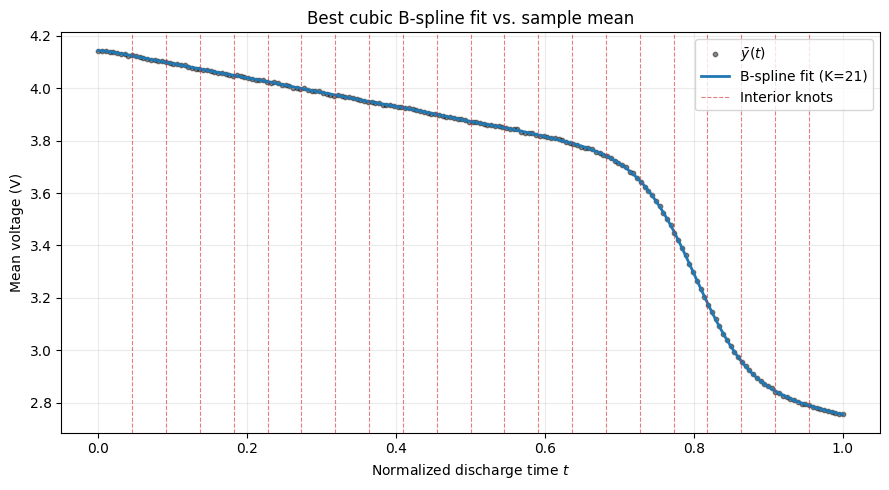

In [29]:
t_dense = np.linspace(0.0, 1.0, 1000)
y_bspline_dense = bspline_fit_predict(t, y_bar, t_dense, n_interior_knots=best_bspline_k)
best_bspline_knots = np.linspace(0.0, 1.0, best_bspline_k + 2)[1:-1]

plt.figure(figsize=(9, 5))
plt.scatter(t, y_bar, s=10, color='black', alpha=0.45, label=r'$\bar y(t)$')
plt.plot(t_dense, y_bspline_dense, color='tab:blue', linewidth=2,
         label=f'B-spline fit (K={best_bspline_k})')
for i, knot in enumerate(best_bspline_knots):
    plt.axvline(knot, color='tab:red', linestyle='--', linewidth=0.8, alpha=0.6,
                label='Interior knots' if i == 0 else None)
plt.xlabel('Normalized discharge time $t$')
plt.ylabel('Mean voltage (V)')
plt.title('Best cubic B-spline fit vs. sample mean')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## (c) Smoothing spline

Choose $\lambda$ by minimizing

$$
\operatorname{GCV}(\lambda)=
\frac{\lVert(I-S_\lambda)y\rVert^2/n}
{(1-\operatorname{tr}(S_\lambda)/n)^2}.
$$

For this question, GCV selects one $\lambda^*$ using the complete sample mean curve. That value is then held fixed while the common five folds calculate CV MSE. The full-data fit supplies the reported $\lambda^*$, $\operatorname{tr}(S_{\lambda^*})$, and final plotted curve.

In [34]:
def roughness_penalty(cardinal_basis):
    """Return Omega[j,k] = integral N_j''(t) N_k''(t) dt."""
    coefficients = cardinal_basis.c
    n_basis = coefficients.shape[2]
    omega = np.zeros((n_basis, n_basis))

    for interval, width in enumerate(np.diff(cardinal_basis.x)):
        # On this interval N_j''(t) = a_j*z + b_j.
        a = 6.0 * coefficients[0, interval, :]
        b = 2.0 * coefficients[1, interval, :]
        omega += np.outer(a, a) * width**3 / 3.0
        omega += (np.outer(a, b) + np.outer(b, a)) * width**2 / 2.0
        omega += np.outer(b, b) * width

    return (omega + omega.T) / 2.0


def fit_natural_smoothing_spline(x, y, lambda_grid):
    """Fit a natural cubic smoothing spline; select lambda by GCV."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    lambda_grid = np.asarray(lambda_grid, dtype=float)

    if np.any(lambda_grid <= 0):
        raise ValueError('All lambda values must be positive.')

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    if np.any(np.diff(x_sorted) <= 0):
        raise ValueError('The time points must be unique.')

    n = len(x_sorted)

    # Columns are the natural cubic cardinal basis functions N_j.
    cardinal_basis = CubicSpline(
        x_sorted, np.eye(n), bc_type='natural', axis=0
    )
    omega = roughness_penalty(cardinal_basis)

    # Eigen form of S_lambda = (I + lambda*Omega)^(-1).
    penalty_eigenvalues, U = np.linalg.eigh(omega)
    penalty_eigenvalues = np.maximum(penalty_eigenvalues, 0.0)
    y_rotated = U.T @ y_sorted

    gcv_values = np.empty(len(lambda_grid))
    df_values = np.empty(len(lambda_grid))

    for j, lam in enumerate(lambda_grid):
        shrinkage = 1.0 / (1.0 + lam * penalty_eigenvalues)
        residual_rotated = (1.0 - shrinkage) * y_rotated
        rss = residual_rotated @ residual_rotated
        df = shrinkage.sum()
        denominator = (1.0 - df / n) ** 2

        gcv_values[j] = (rss / n) / denominator if denominator > 1e-24 else np.inf
        df_values[j] = df

    best_index = int(np.argmin(gcv_values))
    best_lambda = float(lambda_grid[best_index])
    best_shrinkage = 1.0 / (1.0 + best_lambda * penalty_eigenvalues)

    smoother_matrix = (U * best_shrinkage) @ U.T
    theta = smoother_matrix @ y_sorted

    return {
        'lambda': best_lambda,
        'df': float(np.trace(smoother_matrix)),
        'gcv': float(gcv_values[best_index]),
        'gcv_values': gcv_values,
        'df_values': df_values,
        'smoother_matrix': smoother_matrix,
        'theta': theta,
        'basis': cardinal_basis,
    }


def predict_natural_smoothing_spline(model, x_new):
    basis_new = model['basis'](np.asarray(x_new, dtype=float))
    return basis_new @ model['theta']

In [35]:
# Step 1: choose the reported lambda by full-data GCV.
lambda_grid = np.logspace(-14, 4, 361)
smoothing_full = fit_natural_smoothing_spline(t, y_bar, lambda_grid)

best_smoothing_lambda = smoothing_full['lambda']
best_smoothing_df = smoothing_full['df']

if np.argmin(smoothing_full['gcv_values']) in (0, len(lambda_grid) - 1):
    print('Warning: expand lambda_grid because the minimum is on its boundary.')


# Step 2: keep that lambda fixed during the common five-fold CV.
def smoothing_fixed_lambda_fit_predict(
    x_train, y_train, x_valid, lambda_value
):
    model = fit_natural_smoothing_spline(
        x_train, y_train, np.array([lambda_value])
    )
    return predict_natural_smoothing_spline(model, x_valid)


smoothing_cv_mse = cv_mse(
    smoothing_fixed_lambda_fit_predict,
    t,
    y_bar,
    splits,
    lambda_value=best_smoothing_lambda,
)

print(f'Optimal lambda from GCV: {best_smoothing_lambda:.8g}')
print(f'Effective df: {best_smoothing_df:.4f}')
print(f'5-fold CV MSE: {smoothing_cv_mse:.8g}')

Optimal lambda from GCV: 2.2387211e-06
Effective df: 35.4782
5-fold CV MSE: 3.3886575e-06


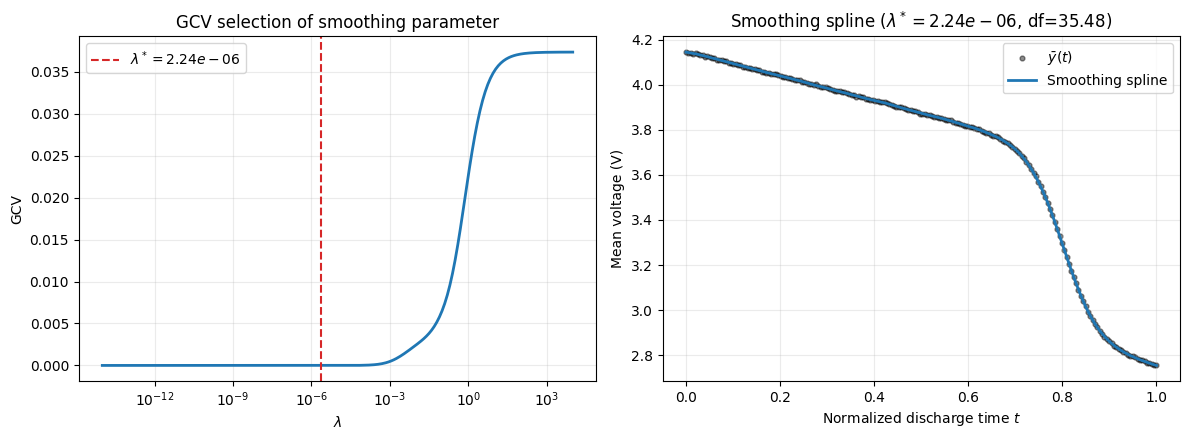

In [36]:
# GCV diagnostic and the final full-data smoothing-spline curve.
t_dense = np.linspace(0.0, 1.0, 1000)
y_smoothing_dense = predict_natural_smoothing_spline(smoothing_full, t_dense)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].semilogx(lambda_grid, smoothing_full['gcv_values'], linewidth=2)
axes[0].axvline(
    best_smoothing_lambda, color='tab:red', linestyle='--',
    label=fr'$\lambda^*={best_smoothing_lambda:.3g}$',
)
axes[0].set_xlabel(r'$\lambda$')
axes[0].set_ylabel('GCV')
axes[0].set_title('GCV selection of smoothing parameter')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].scatter(
    t, y_bar, s=12, color='black', alpha=0.45, label=r'$\bar y(t)$'
)
axes[1].plot(
    t_dense, y_smoothing_dense, color='tab:blue', linewidth=2,
    label='Smoothing spline',
)
axes[1].set_xlabel('Normalized discharge time $t$')
axes[1].set_ylabel('Mean voltage (V)')
axes[1].set_title(
    fr'Smoothing spline ($\lambda^*={best_smoothing_lambda:.3g}$, '
    fr'df={best_smoothing_df:.2f})'
)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## (d) Gaussian kernel regression

Use the Nadaraya--Watson estimator

$$
\hat f(t)=\frac{\sum_i \exp[-(t-t_i)^2/(2h^2)]y_i}
{\sum_i \exp[-(t-t_i)^2/(2h^2)]}.
$$

Choose a reasonable positive bandwidth grid, plot CV MSE against $h$, and refine the grid near its minimum.

In [37]:
def kernel_fit_predict(
    x_train,
    y_train,
    x_valid,
    bandwidth,
):
    """
    Nadaraya-Watson regression with a Gaussian kernel.
    """
    if bandwidth <= 0:
        raise ValueError("bandwidth must be positive")

    x_train = np.asarray(x_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    x_valid = np.asarray(x_valid, dtype=float)

    scaled_distance = (
        x_valid[:, None] - x_train[None, :]
    ) / bandwidth

    log_weights = -0.5 * scaled_distance**2

    # Numerical stabilization for small bandwidths
    log_weights -= log_weights.max(axis=1, keepdims=True)
    weights = np.exp(log_weights)

    return (weights @ y_train) / weights.sum(axis=1)

In [38]:
# 5-fold CV search
bandwidth_grid = np.logspace(
    np.log10(0.001),
    np.log10(0.5),
    100,
)

kernel_cv = {}

for bandwidth in bandwidth_grid:
    kernel_cv[bandwidth] = cv_mse(
        kernel_fit_predict,
        t,
        y_bar,
        splits,
        bandwidth=bandwidth,
    )

best_bandwidth = min(
    kernel_cv,
    key=kernel_cv.get,
)

best_kernel_mse = kernel_cv[best_bandwidth]

print(f"Optimal bandwidth: {best_bandwidth:.8g}")
print(f"Kernel regression CV MSE: {best_kernel_mse:.8g}")

Optimal bandwidth: 0.0070005477
Kernel regression CV MSE: 1.2364446e-05


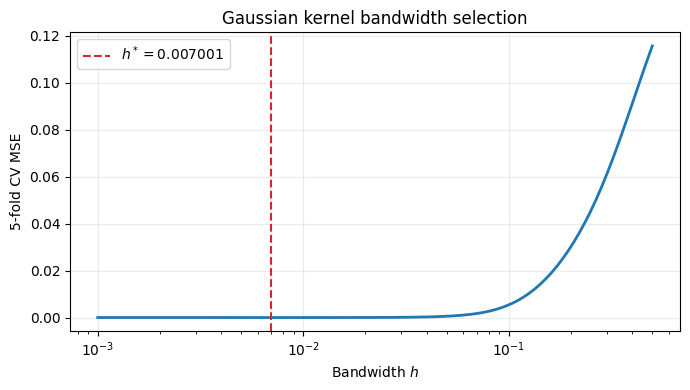

In [40]:
# Check that the minimum is not on the boundary of the search grid
best_bandwidth_index = np.argmin(
    list(kernel_cv.values())
)

if best_bandwidth_index in (0, len(bandwidth_grid) - 1):
    print(
        "Warning: the optimal bandwidth is on the grid boundary. "
        "Expand bandwidth_grid."
    )

# Plot CV MSE against bandwidth
plt.figure(figsize=(7, 4))

plt.semilogx(
    bandwidth_grid,
    list(kernel_cv.values()),
    linewidth=2,
)

plt.axvline(
    best_bandwidth,
    color="tab:red",
    linestyle="--",
    label=fr"$h^*={best_bandwidth:.4g}$",
)

plt.xlabel("Bandwidth $h$")
plt.ylabel("5-fold CV MSE")
plt.title("Gaussian kernel bandwidth selection")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## (e) Results table and final plot

Refit every selected model on all 200 points, predict on a dense grid, complete the table, and plot the four fits with $\bar y(t)$.

In [43]:
t_dense = np.linspace(0.0, 1.0, 1000)

# Selected truncated-power spline
y_truncated_dense = truncated_power_fit_predict(
    t,
    y_bar,
    t_dense,
    n_interior_knots=best_truncated_k,
)

# Selected cubic B-spline
y_bspline_dense = bspline_fit_predict(
    t,
    y_bar,
    t_dense,
    n_interior_knots=best_bspline_k,
)

# Selected smoothing spline
y_smoothing_dense = predict_natural_smoothing_spline(
    smoothing_full,
    t_dense,
)

# Selected Gaussian kernel regression
y_kernel_dense = kernel_fit_predict(
    t,
    y_bar,
    t_dense,
    bandwidth=best_bandwidth,
)

In [44]:
results = pd.DataFrame(
    [
        {
            "Method": "Truncated-power cubic spline",
            "Selected parameter": (
                f"{best_truncated_k} interior knots"
            ),
            "CV MSE": best_truncated_mse,
        },
        {
            "Method": "Cubic B-spline",
            "Selected parameter": (
                f"{best_bspline_k} interior knots"
            ),
            "CV MSE": best_bspline_mse,
        },
        {
            "Method": "Smoothing spline",
            "Selected parameter": (
                f"lambda={best_smoothing_lambda:.4g}, "
                f"df={best_smoothing_df:.2f}"
            ),
            "CV MSE": smoothing_cv_mse,
        },
        {
            "Method": "Gaussian kernel regression",
            "Selected parameter": (
                f"h={best_bandwidth:.4g}"
            ),
            "CV MSE": best_kernel_mse,
        },
    ]
)

display(
    results.style.format(
        {"CV MSE": "{:.8g}"}
    )
)

,Method,Selected parameter,CV MSE
0,Truncated-power cubic spline,21 interior knots,3.262595e-06
1,Cubic B-spline,21 interior knots,3.262595e-06
2,Smoothing spline,"lambda=2.239e-06, df=35.48",3.3886575e-06
3,Gaussian kernel regression,h=0.007001,1.2364446e-05


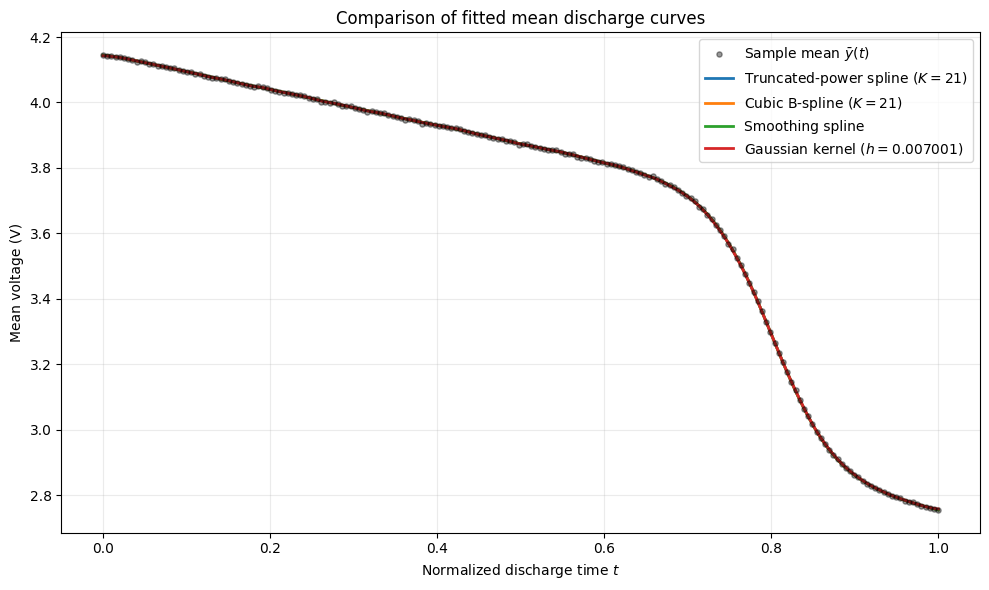

In [45]:
plt.figure(figsize=(10, 6))

plt.scatter(
    t,
    y_bar,
    s=14,
    color="black",
    alpha=0.4,
    label=r"Sample mean $\bar y(t)$",
    zorder=5,
)

plt.plot(
    t_dense,
    y_truncated_dense,
    linewidth=2,
    label=(
        "Truncated-power spline "
        f"($K={best_truncated_k}$)"
    ),
)

plt.plot(
    t_dense,
    y_bspline_dense,
    linewidth=2,
    label=(
        "Cubic B-spline "
        f"($K={best_bspline_k}$)"
    ),
)

plt.plot(
    t_dense,
    y_smoothing_dense,
    linewidth=2,
    label="Smoothing spline",
)

plt.plot(
    t_dense,
    y_kernel_dense,
    linewidth=2,
    label=(
        "Gaussian kernel "
        f"($h={best_bandwidth:.4g}$)"
    ),
)

plt.xlabel("Normalized discharge time $t$")
plt.ylabel("Mean voltage (V)")
plt.title("Comparison of fitted mean discharge curves")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Select the model with the lowest CV MSE
best_result_index = results["CV MSE"].idxmin()
best_result = results.loc[best_result_index]

print(
    f"Selected model: {best_result['Method']}\n"
    f"CV MSE: {best_result['CV MSE']:.8g}"
)

Selected model: Truncated-power cubic spline
CV MSE: 3.262595e-06


I selected the model with the smallest five-fold CV MSE, i.e. Truncated-power cubic spline because it had the best held-out prediction performance on the common time-point splits. Its fitted curve also follows the overall shape of the sample mean without introducing unnecessary oscillations.